In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# Load German Credit dataset directly from sklearn (no download needed)
credit = fetch_openml('credit-g', version=1, as_frame=True)
df = credit.frame

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Shape: (1000, 21)

Columns: ['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker', 'class']

First 5 rows:
  checking_status  duration                  credit_history  \
0              <0         6  critical/other existing credit   
1        0<=X<200        48                   existing paid   
2     no checking        12  critical/other existing credit   
3              <0        42                   existing paid   
4              <0        24              delayed previously   

               purpose  credit_amount    savings_status employment  \
0             radio/tv           1169  no known savings        >=7   
1             radio/tv           5951              <100     1<=X<4   
2            education   

In [12]:
# Check data types and missing values
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1

In [14]:
print(df.columns.tolist())

['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker', 'class']


In [16]:
print(df['class'].value_counts())

class
good    700
bad     300
Name: count, dtype: int64


In [17]:
df['class'] = df['class'].map({'good': 1, 'bad': 0})
print(df['class'].value_counts())

class
1    700
0    300
Name: count, dtype: int64


In [18]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include='category').columns.tolist()
cat_cols.remove('class')  # already encoded above

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Categorical columns encoded:", cat_cols)
print(df.head())

Categorical columns encoded: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']
   checking_status  duration  credit_history  purpose  credit_amount  \
0                1         6               1        6           1169   
1                0        48               3        6           5951   
2                3        12               1        2           2096   
3                1        42               3        3           7882   
4                1        24               2        4           4870   

   savings_status  employment  installment_commitment  personal_status  \
0               4           3                       4                3   
1               2           0                       2                0   
2               2           1                       2                3   
3               2          

In [19]:
# Feature 1: credit amount per month (how heavy is the loan relative to duration)
df['credit_per_month'] = df['credit_amount'] / df['duration']

# Feature 2: age-to-employment ratio (stability indicator)
df['debt_to_duration'] = df['credit_amount'] / (df['age'] + 1)

print("New features added. Shape now:", df.shape)

New features added. Shape now: (1000, 23)


In [20]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (800, 22)
Test size: (200, 22)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling done.")

Scaling done.


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['Bad Credit', 'Good Credit']))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]))

=== Logistic Regression ===
              precision    recall  f1-score   support

  Bad Credit       0.49      0.37      0.42        60
 Good Credit       0.75      0.84      0.79       140

    accuracy                           0.69       200
   macro avg       0.62      0.60      0.61       200
weighted avg       0.68      0.69      0.68       200

ROC-AUC: 0.733095238095238


In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['Bad Credit', 'Good Credit']))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

=== Random Forest ===
              precision    recall  f1-score   support

  Bad Credit       0.68      0.42      0.52        60
 Good Credit       0.79      0.91      0.84       140

    accuracy                           0.77       200
   macro avg       0.73      0.67      0.68       200
weighted avg       0.75      0.77      0.75       200

ROC-AUC: 0.7867261904761904


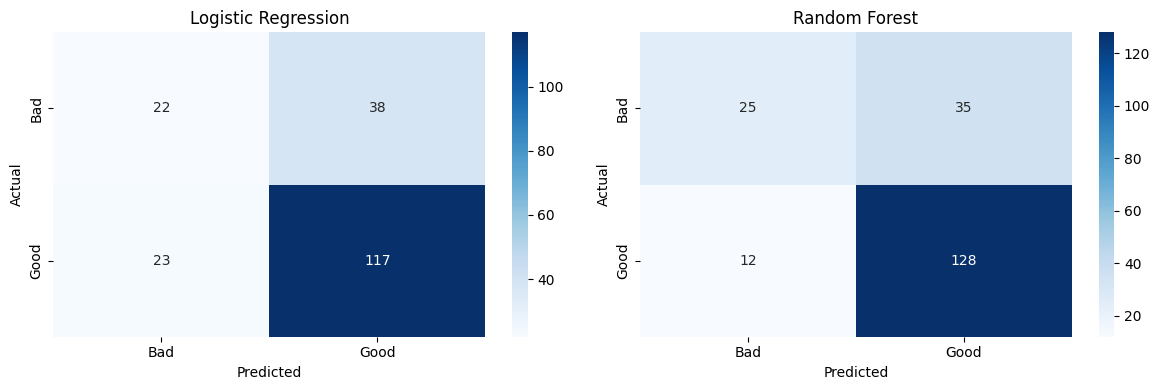

Saved: confusion_matrix.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, preds, title in zip(
    axes,
    [lr, rf],
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

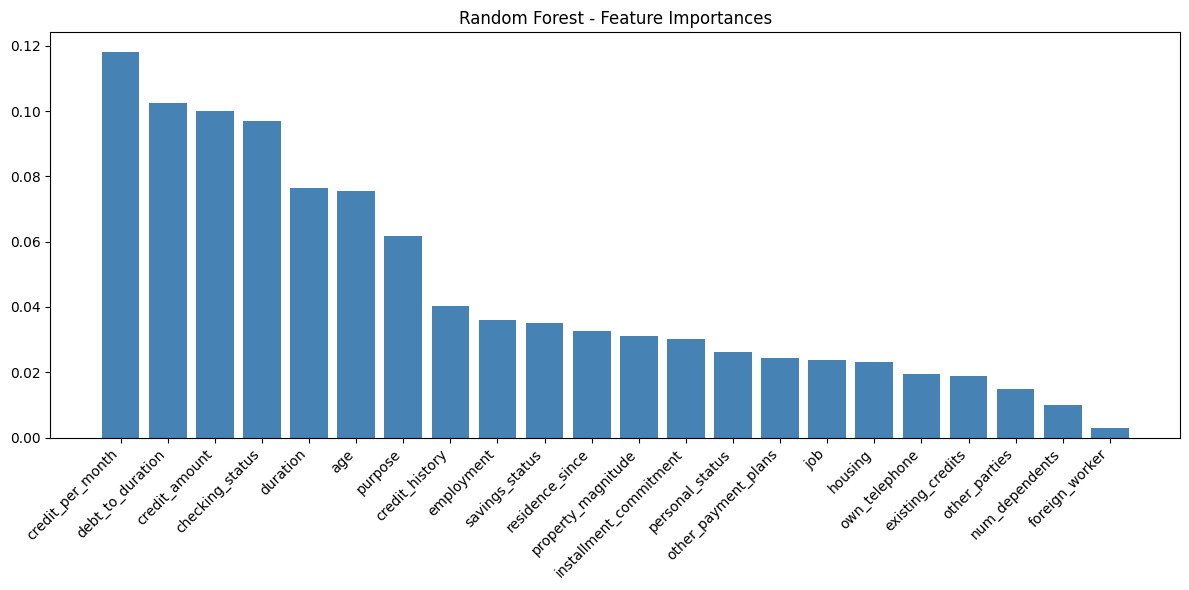

Saved: feature_importance.png


In [25]:
feature_names = df.drop(columns=['class']).columns.tolist()

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(importances)), importances[indices], color='steelblue')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Random Forest - Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Saved: feature_importance.png")